In [10]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [11]:
class BatsmanState(TypedDict):

    runs: int
    balls: int
    fours: int
    sixes: int

    sr: float
    bpb: float
    boundary_percent: float
    summary: str

In [12]:
def calculate_sr(state: BatsmanState):

    sr = (state['runs']/state['balls']) * 100

    return {'sr': sr}

In [13]:
def calculate_bpb(state: BatsmanState):

    bpb = state['balls'] / (state['fours'] + state['sixes'])

    return {'bpb': bpb}

In [14]:
def calculate_boundary_percent(state: BatsmanState):

    boundary_percent = ((state['fours'] + state['sixes']) / state['balls']) * 100

    return {'boundary_percent': boundary_percent}

In [15]:
def calculate_summary(state: BatsmanState):

    summary = f"""
Runs: {state['runs']} \n
Balls: {state['balls']} \n
Fours: {state['fours']} \n
Sixes: {state['sixes']} \n
Strike Rate: {state['sr']} \n
Boundary per Ball: {state['bpb']} \n
Boundary Percent: {state['boundary_percent']} \n
"""

In [16]:
# define graph
graph = StateGraph(BatsmanState)

# add nodes
graph.add_node('calculate_sr', calculate_sr)
graph.add_node('calculate_bpb', calculate_bpb)
graph.add_node('calculate_boundary_percent', calculate_boundary_percent)
graph.add_node('calculate_summary', calculate_summary)

#add edges
graph.add_edge(START, 'calculate_sr')
graph.add_edge(START, 'calculate_bpb')
graph.add_edge(START, 'calculate_boundary_percent')

graph.add_edge('calculate_sr', 'calculate_summary')
graph.add_edge('calculate_bpb', 'calculate_summary')
graph.add_edge('calculate_boundary_percent', 'calculate_summary')

graph.add_edge('calculate_summary', END)

# compile graph
workflow = graph.compile()

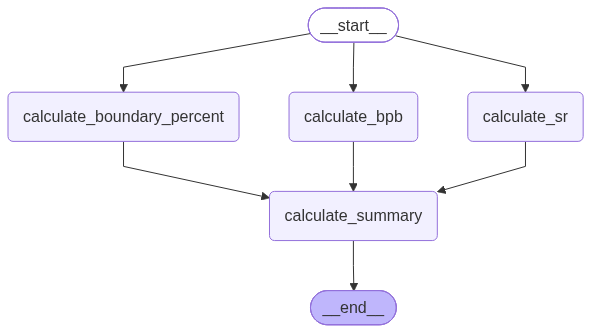

In [17]:
workflow

In [19]:
initial_state = {'runs': 100, 'balls': 60, 'fours': 10, 'sixes': 5}

final_state = workflow.invoke(initial_state)

print(final_state)

{'runs': 100, 'balls': 60, 'fours': 10, 'sixes': 5, 'sr': 166.66666666666669, 'bpb': 4.0, 'boundary_percent': 25.0}
